# Confiabilidad y criterio de reutilización de bombas PCP
## Método gráfico, máxima verosimilitud, censura e intervalos de confianza

Este cuaderno construye un ejemplo reproducible inspirado en el paper **“Reuse Selection Criteria for Progressive Cavity Pumps Based on the Mean Time between Failure and Reliability Function for Each Pump Type in the Cira Infantas Field”**. Se utiliza información anonimizada y sintética parecida en estructura, pero no se reconstruyen ni se atribuyen datos reales del campo.

### Pregunta de ingeniería
Para una bomba PCP recuperada después de cierto tiempo operativo:

1. ¿Cuál es la distribución de su vida hasta falla?
2. ¿Cuál es la confiabilidad $R(t)$, la probabilidad acumulada de falla $F(t)$ y la tasa instantánea de falla $h(t)$?
3. ¿Qué diferencia existe entre estimar Weibull gráficamente y mediante máxima verosimilitud?
4. ¿Cuál es la incertidumbre de los parámetros y de las curvas?
5. ¿Cuál es la probabilidad condicional de operar **365 días adicionales** si la bomba ya acumuló cierta edad?

> **Alcance:** ejemplo educativo con datos sintéticos. La decisión real también requiere inspección visual, borescopio, prueba de banco, eficiencia, modo de falla, condiciones del pozo y revisión de ingeniería.

## 1. Relación con el paper

El paper organiza historiales por modelo de bomba, clasifica las intervenciones como falla de bomba o no falla, calcula MTBF y utiliza curvas de supervivencia para apoyar la reutilización. El criterio propuesto combina inspección física, una eficiencia de banco superior al 50 %, un MTBF del modelo superior a 730 días y una probabilidad superior al 50 % de sobrevivir 365 días adicionales. También reporta para un modelo ilustrativo un MTBF de 994 días y una vida mediana aproximada de 650 días.

Este cuaderno conserva la lógica de decisión, pero fortalece el tratamiento estadístico mediante:

- censura derecha explícita;
- Kaplan-Meier como referencia no paramétrica;
- Weibull por método gráfico;
- Weibull por máxima verosimilitud con censura;
- intervalos de confianza bootstrap;
- confiabilidad residual condicional, en lugar de restar mecánicamente edad a una vida característica.

**Diferencia importante:** $MTBF-edad$ no es, en general, la vida remanente esperada. En una Weibull no exponencial, la vida residual depende de la edad y de la forma $\beta$.

## 2. Notación y funciones Weibull

Para $T\sim Weibull(\beta,\eta)$:

$$f(t)=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}\exp\left[-\left(\frac{t}{\eta}\right)^\beta\right]$$

$$R(t)=P(T>t)=\exp\left[-\left(\frac{t}{\eta}\right)^\beta\right]$$

$$F(t)=P(T\le t)=1-R(t)$$

$$h(t)=\frac{f(t)}{R(t)}=\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}$$

- $\beta<1$: tasa de falla decreciente.
- $\beta=1$: tasa constante, caso exponencial.
- $\beta>1$: tasa creciente, compatible con desgaste bajo el modelo.
- $\eta$: vida característica, donde $F(\eta)=63,2\%$.
- Media o MTTF del ajuste: $E[T]=\eta\Gamma(1+1/\beta)$.
- Vida $B_p$: tiempo al que ha fallado el $p\%$, $B_p=\eta[-\ln(1-p)]^{1/\beta}$.

Para una bomba que ya sobrevivió hasta edad $a$, la confiabilidad por $\Delta$ días adicionales es:

$$P(T>a+\Delta\mid T>a)=\frac{R(a+\Delta)}{R(a)}.$$

Esta probabilidad condicional es la métrica central para reutilización.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize, special

SEED = 173940
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (10, 5.8), "axes.titlesize": 14,
                     "axes.labelsize": 12, "legend.fontsize": 10})
print("Semilla:", SEED)

Semilla: 173940


## 3. Construcción de datos anonimizados

Se simulan 60 instalaciones de un modelo anónimo `PCP-A20`.

### Operaciones
1. Generar una vida potencial Weibull, no observable directamente para todas las bombas.
2. Generar un tiempo de salida por intervención ajena a la bomba o fin de seguimiento.
3. Registrar $t_i=\min(T_i,C_i)$.
4. Definir $\delta_i=1$ si hubo falla de bomba antes de la censura, y $0$ en caso contrario.
5. Añadir variables operativas para mostrar la estructura de una base real. Estas variables no entran en el ajuste Weibull básico.

Una observación censurada en 700 días **no significa** que la bomba falló a los 700 días. Significa que se sabe que sobrevivió al menos hasta 700 días.

In [2]:
n = 60
beta_data, eta_data = 1.55, 1050.0
vida_latente = eta_data * rng.weibull(beta_data, n)
# Censura por intervención ajena, cambio operacional o corte administrativo
censura = np.minimum(rng.uniform(500, 1450, n), 1250)
tiempo = np.minimum(vida_latente, censura)
evento = (vida_latente <= censura).astype(int)

datos = pd.DataFrame({
    "id_bomba": [f"PCP-{i:03d}" for i in range(1, n+1)],
    "modelo": "PCP-A20",
    "tiempo_dias": np.round(tiempo, 1),
    "evento_falla": evento,
    "eficiencia_banco_pct": np.round(rng.uniform(45, 82, n), 1),
    "corte_agua_pct": np.round(rng.uniform(72, 98, n), 1),
    "rpm": rng.integers(120, 280, n)
}).sort_values("tiempo_dias").reset_index(drop=True)

display(datos.head(10))
print(f"Instalaciones: {len(datos)}")
print(f"Fallas observadas: {datos.evento_falla.sum()}")
print(f"Censuradas: {(1-datos.evento_falla).sum()}")
print(f"Fracción censurada: {(1-datos.evento_falla).mean():.1%}")

,id_bomba,modelo,tiempo_dias,evento_falla,eficiencia_banco_pct,corte_agua_pct,rpm
0,PCP-014,PCP-A20,86.8,1,64.2,85.9,206
1,PCP-019,PCP-A20,90.4,1,57.8,79.7,258
2,PCP-004,PCP-A20,127.2,1,79.2,96.3,122
3,PCP-026,PCP-A20,133.7,1,65.4,88.2,210
4,PCP-032,PCP-A20,200.2,1,70.5,73.5,278
5,PCP-034,PCP-A20,236.3,1,52.2,82.5,261
6,PCP-024,PCP-A20,257.8,1,79.9,92.2,198
7,PCP-002,PCP-A20,277.4,1,74.4,97.2,131
8,PCP-052,PCP-A20,300.6,1,68.3,83.9,120
9,PCP-044,PCP-A20,430.6,1,58.4,92.5,135


Instalaciones: 60
Fallas observadas: 34
Censuradas: 26
Fracción censurada: 43.3%


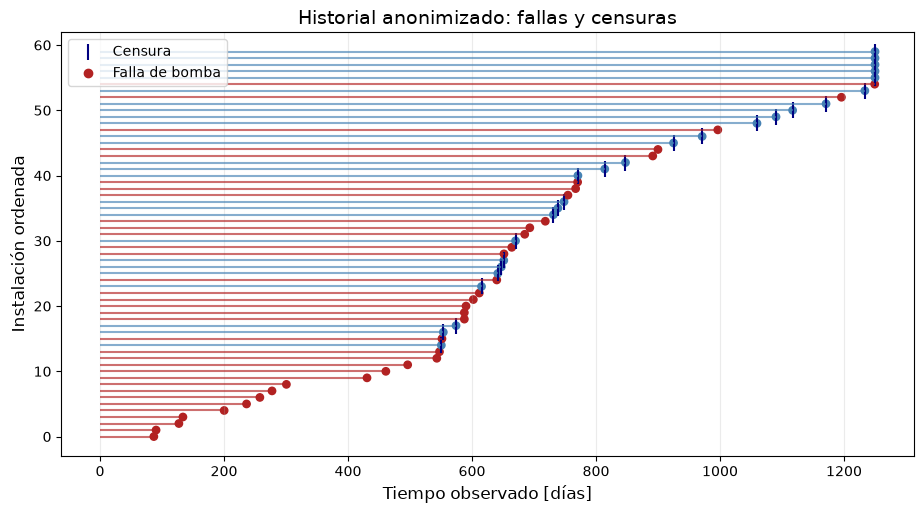

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))
y = np.arange(len(datos))
colores = np.where(datos.evento_falla.eq(1), "firebrick", "steelblue")
ax.hlines(y, 0, datos.tiempo_dias, color=colores, alpha=.65)
ax.scatter(datos.tiempo_dias, y, c=colores, s=28)
ax.scatter(datos.loc[datos.evento_falla.eq(0), "tiempo_dias"],
           y[datos.evento_falla.eq(0)], marker="|", color="navy", s=120, label="Censura")
ax.scatter([], [], color="firebrick", label="Falla de bomba")
ax.set(xlabel="Tiempo observado [días]", ylabel="Instalación ordenada",
       title="Historial anonimizado: fallas y censuras")
ax.legend(); ax.grid(axis="x", alpha=.25); plt.show()

## 4. Referencia no paramétrica: Kaplan-Meier

Kaplan-Meier estima supervivencia sin imponer Weibull:

$$\widehat R_{KM}(t)=\prod_{t_j\le t}\left(1-\frac{d_j}{n_j}\right),$$

donde $d_j$ es el número de fallas en $t_j$ y $n_j$ es el número en riesgo justo antes. Las censuras reducen el conjunto en riesgo después de su tiempo, pero no generan un salto de falla.

Se usa el intervalo log-log de Greenwood para mantener límites dentro de $[0,1]$.

,tiempo,en_riesgo,fallas,R_KM,IC_inf,IC_sup
0,86.8,60,1,0.983333,0.887526,0.997635
1,90.4,59,1,0.966667,0.873225,0.991558
2,127.2,58,1,0.950000,0.852947,0.983595
3,133.7,57,1,0.933333,0.832052,0.974443
4,200.2,56,1,0.916667,0.811310,0.964441
5,236.3,55,1,0.900000,0.790882,0.953785
6,257.8,54,1,0.883333,0.770792,0.942601
7,277.4,53,1,0.866667,0.751026,0.930976
8,300.6,52,1,0.850000,0.731563,0.918971
9,430.6,51,1,0.833333,0.712380,0.906636


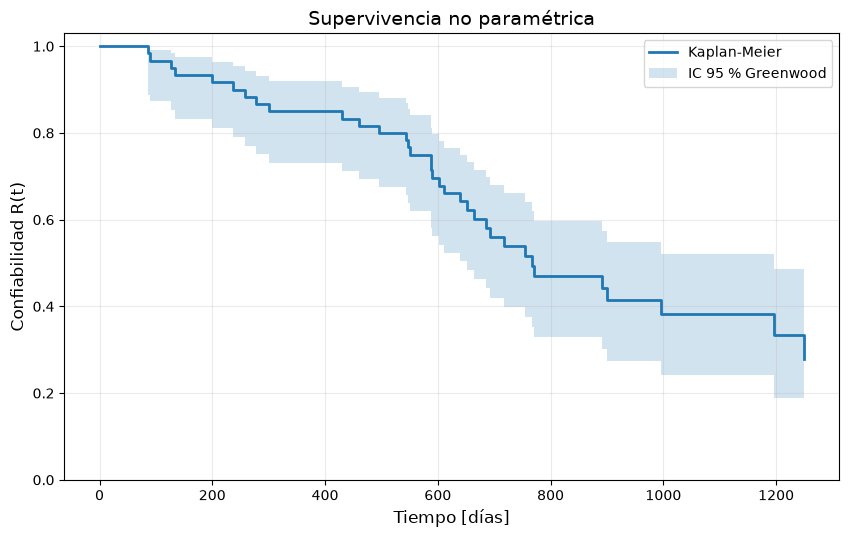

In [4]:
def kaplan_meier(time, event, alpha=.05):
    df=pd.DataFrame({"t":time,"e":event}).sort_values("t")
    event_times=np.sort(df.loc[df.e.eq(1),"t"].unique())
    S=1.; green=0.; rows=[]; z=stats.norm.ppf(1-alpha/2)
    for t in event_times:
        n_risk=(df.t>=t).sum(); d=((df.t==t)&(df.e==1)).sum()
        S *= (1-d/n_risk)
        if n_risk>d: green += d/(n_risk*(n_risk-d))
        if 0<S<1 and green>0:
            se_loglog=np.sqrt(green)/abs(np.log(S))
            lo=np.exp(-np.exp(np.log(-np.log(S))+z*se_loglog))
            hi=np.exp(-np.exp(np.log(-np.log(S))-z*se_loglog))
        else: lo=hi=S
        rows.append((t,n_risk,d,S,lo,hi))
    return pd.DataFrame(rows,columns=["tiempo","en_riesgo","fallas","R_KM","IC_inf","IC_sup"])

km=kaplan_meier(datos.tiempo_dias.values,datos.evento_falla.values)
display(km.head(10))

fig,ax=plt.subplots(figsize=(10,5.8))
ax.step(np.r_[0,km.tiempo],np.r_[1,km.R_KM],where="post",lw=2,label="Kaplan-Meier")
ax.fill_between(np.r_[0,km.tiempo],np.r_[1,km.IC_inf],np.r_[1,km.IC_sup],step="post",alpha=.2,label="IC 95 % Greenwood")
ax.set(xlabel="Tiempo [días]",ylabel="Confiabilidad R(t)",title="Supervivencia no paramétrica",ylim=(0,1.03))
ax.legend(); ax.grid(alpha=.25); plt.show()

## 5. Método gráfico Weibull

La transformación Weibull convierte la curva en una recta:

$$Y=\ln[-\ln R(t)]=\beta\ln(t)-\beta\ln(\eta)=\beta X+b.$$

### Operaciones explícitas
1. Tomar los tiempos de falla, no los tiempos censurados como si fueran fallas.
2. Asignar a cada falla la supervivencia Kaplan-Meier inmediatamente después del salto.
3. Calcular $X=\ln(t)$.
4. Calcular $Y=\ln[-\ln(\widehat R_{KM}(t))]$.
5. Ajustar $Y=b+\beta X$ por mínimos cuadrados.
6. Recuperar $\eta=\exp(-b/\beta)$.

Es un método visual y útil para diagnóstico. La regresión no reproduce exactamente la estructura probabilística de los datos censurados, por lo cual la máxima verosimilitud es preferible para inferencia formal.

Pendiente = beta gráfico = 1.4503
Intercepto = -10.1719
eta gráfico = exp(-intercepto/beta) = 1111.76 días
R² de linealidad = 0.9627


,tiempo,R_KM,X_log_t,Y_weibull,Y_ajustada
0,86.8,0.983333,4.463607,-4.085953,-3.698384
1,90.4,0.966667,4.504244,-3.384294,-3.639447
2,127.2,0.950000,4.845761,-2.970195,-3.144149
3,133.7,0.933333,4.895598,-2.673752,-3.071869
4,200.2,0.916667,5.299317,-2.441716,-2.486360
5,236.3,0.900000,5.465102,-2.250367,-2.245923
6,257.8,0.883333,5.552184,-2.087049,-2.119628
7,277.4,0.866667,5.625461,-1.944206,-2.013356
8,300.6,0.850000,5.705780,-1.816961,-1.896869
9,430.6,0.833333,6.065180,-1.701983,-1.375635


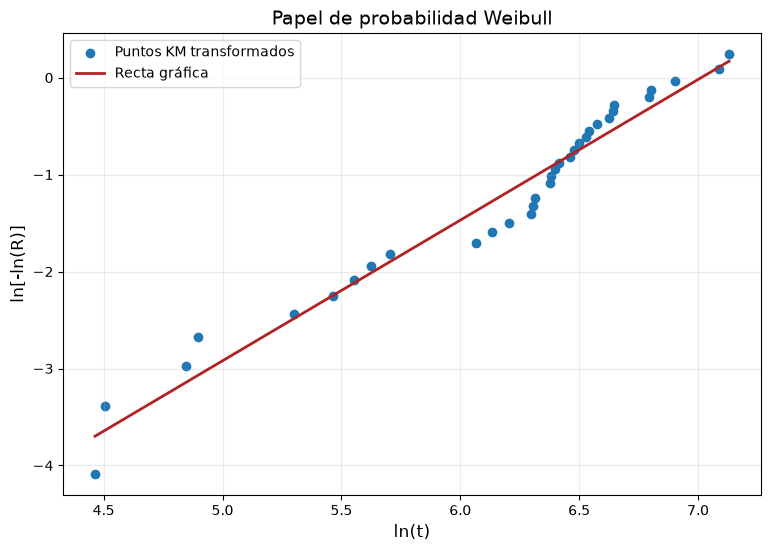

In [5]:
plot_df=km.query("R_KM > 0 and R_KM < 1").copy()
plot_df["X_log_t"]=np.log(plot_df.tiempo)
plot_df["Y_weibull"]=np.log(-np.log(plot_df.R_KM))
beta_g, intercepto_g=np.polyfit(plot_df.X_log_t,plot_df.Y_weibull,1)
eta_g=np.exp(-intercepto_g/beta_g)
plot_df["Y_ajustada"]=intercepto_g+beta_g*plot_df.X_log_t
r2=1-np.sum((plot_df.Y_weibull-plot_df.Y_ajustada)**2)/np.sum((plot_df.Y_weibull-plot_df.Y_weibull.mean())**2)

print(f"Pendiente = beta gráfico = {beta_g:.4f}")
print(f"Intercepto = {intercepto_g:.4f}")
print(f"eta gráfico = exp(-intercepto/beta) = {eta_g:.2f} días")
print(f"R² de linealidad = {r2:.4f}")

display(plot_df[["tiempo","R_KM","X_log_t","Y_weibull","Y_ajustada"]].head(10))
fig,ax=plt.subplots(figsize=(9,6))
ax.scatter(plot_df.X_log_t,plot_df.Y_weibull,label="Puntos KM transformados")
xx=np.linspace(plot_df.X_log_t.min(),plot_df.X_log_t.max(),100)
ax.plot(xx,intercepto_g+beta_g*xx,color="firebrick",lw=2,label="Recta gráfica")
ax.set(xlabel="ln(t)",ylabel="ln[-ln(R)]",title="Papel de probabilidad Weibull")
ax.legend(); ax.grid(alpha=.25); plt.show()

## 6. Máxima verosimilitud con censura derecha

Cada falla aporta la densidad $f(t_i)$ y cada censura aporta la supervivencia $R(t_i)$:

$$L(\beta,\eta)=\prod_i f(t_i)^{\delta_i}R(t_i)^{1-\delta_i}.$$

La log-verosimilitud Weibull simplificada es:

$$\ell=\sum_i\left[\delta_i\left(\ln\beta-\ln\eta+(\beta-1)\ln(t_i/\eta)\right)-(t_i/\eta)^\beta\right].$$

Se optimiza en $\theta=(\ln\beta,\ln\eta)$ para asegurar parámetros positivos. Minimizar la log-verosimilitud negativa equivale a maximizar $\ell$.

In [6]:
t=datos.tiempo_dias.to_numpy(float); d=datos.evento_falla.to_numpy(int)

def nll_logpars(logpars,time,event):
    beta,eta=np.exp(logpars)
    ll=event*(np.log(beta)-np.log(eta)+(beta-1)*np.log(time/eta))-(time/eta)**beta
    return -np.sum(ll)

inicio=np.log([beta_g,eta_g])
fit=optimize.minimize(nll_logpars,inicio,args=(t,d),method="BFGS")
if not fit.success:
    fit=optimize.minimize(nll_logpars,inicio,args=(t,d),method="Nelder-Mead")
beta_mle,eta_mle=np.exp(fit.x)
loglik=-nll_logpars(fit.x,t,d)
AIC=2*2-2*loglik
MTTF=eta_mle*special.gamma(1+1/beta_mle)
B10=eta_mle*(-np.log(.90))**(1/beta_mle)
B50=eta_mle*(np.log(2))**(1/beta_mle)

print("Convergencia:",fit.success,fit.message)
print(f"beta MLE = {beta_mle:.4f}")
print(f"eta MLE = {eta_mle:.2f} días")
print(f"Log-verosimilitud = {loglik:.3f}; AIC = {AIC:.3f}")
print(f"Media Weibull ajustada = {MTTF:.1f} días")
print(f"B10 = {B10:.1f} días; B50 = {B50:.1f} días")

Convergencia: True Optimization terminated successfully.
beta MLE = 1.6313
eta MLE = 1071.85 días
Log-verosimilitud = -272.183; AIC = 548.366
Media Weibull ajustada = 959.4 días
B10 = 269.8 días; B50 = 856.2 días


## 7. Comparación del método gráfico y MLE

Diferencias moderadas son normales porque:

- el método gráfico ajusta una recta a estimaciones transformadas;
- los puntos no tienen igual varianza;
- Kaplan-Meier incorpora la censura por escalones;
- MLE utiliza directamente la contribución de falla o supervivencia de cada observación.

La linealidad del gráfico es un diagnóstico de plausibilidad Weibull, no una prueba definitiva.

In [7]:
comparacion=pd.DataFrame({
    "metodo":["Gráfico KM-Weibull","Máxima verosimilitud"],
    "beta_forma":[beta_g,beta_mle],"eta_escala_dias":[eta_g,eta_mle],
    "MTTF_weibull_dias":[eta_g*special.gamma(1+1/beta_g),MTTF],
    "B50_dias":[eta_g*np.log(2)**(1/beta_g),B50]})
display(comparacion.style.format({c:"{:.2f}" for c in comparacion.columns if c!="metodo"}))

,metodo,beta_forma,eta_escala_dias,MTTF_weibull_dias,B50_dias
0,Gráfico KM-Weibull,1.45,1111.76,1008.03,863.49
1,Máxima verosimilitud,1.63,1071.85,959.35,856.17


## 8. Intervalos de confianza bootstrap

Se aplica bootstrap no paramétrico por instalaciones:

1. Muestrear con reemplazo 60 filas completas $(t_i,\delta_i)$.
2. Reajustar Weibull MLE en cada muestra.
3. Repetir 1.000 veces.
4. Usar percentiles 2,5 % y 97,5 % para parámetros y métricas.
5. Evaluar $R(t)$, $F(t)$ y $h(t)$ en cada ajuste para construir bandas puntuales.

Estas bandas expresan incertidumbre de muestreo **condicionada a que Weibull sea el modelo correcto**. No incorporan incertidumbre por elegir otra familia, errores de clasificación, dependencia entre reinstalaciones ni cambios de condiciones operativas.

Ajustes bootstrap válidos: 1000 de 1000


,estimacion,IC95_inf,IC95_sup
beta,1.63,1.24,2.18
eta,1071.85,880.29,1406.30
MTTF,959.35,784.26,1283.69
B10,269.80,182.08,387.88
B50,856.17,700.51,1085.13


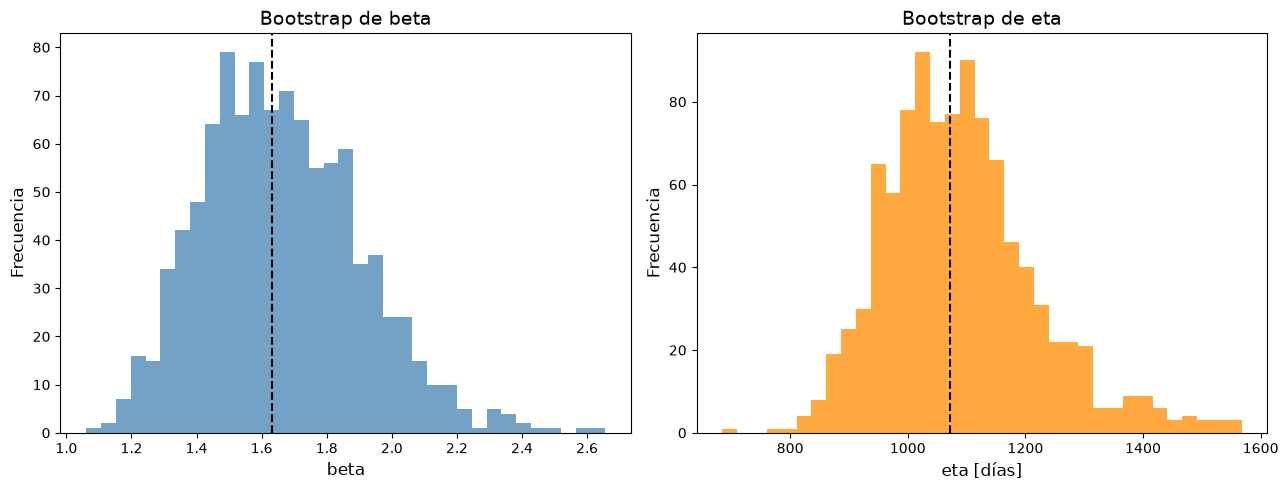

In [8]:
def fit_weibull(time,event,start=None):
    if event.sum()<2: return None
    x0=np.log([beta_mle,eta_mle]) if start is None else start
    r=optimize.minimize(nll_logpars,x0,args=(time,event),method="BFGS")
    if not r.success:
        r=optimize.minimize(nll_logpars,x0,args=(time,event),method="Nelder-Mead")
    return np.exp(r.x) if np.all(np.isfinite(r.x)) else None

B=1000; boot=[]; brng=np.random.default_rng(SEED+1)
for b in range(B):
    idx=brng.integers(0,len(t),len(t)); pars=fit_weibull(t[idx],d[idx])
    if pars is not None:
        bb,ee=pars
        boot.append((bb,ee,ee*special.gamma(1+1/bb),ee*(-np.log(.9))**(1/bb),ee*np.log(2)**(1/bb)))
boot=pd.DataFrame(boot,columns=["beta","eta","MTTF","B10","B50"])
print(f"Ajustes bootstrap válidos: {len(boot)} de {B}")

estimados=pd.Series({"beta":beta_mle,"eta":eta_mle,"MTTF":MTTF,"B10":B10,"B50":B50})
ici=pd.DataFrame({"estimacion":estimados,"IC95_inf":boot.quantile(.025),"IC95_sup":boot.quantile(.975)})
display(ici.style.format("{:.2f}"))

fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].hist(boot.beta,bins=35,color="steelblue",alpha=.75); ax[0].axvline(beta_mle,color="black",ls="--"); ax[0].set(title="Bootstrap de beta",xlabel="beta",ylabel="Frecuencia")
ax[1].hist(boot.eta,bins=35,color="darkorange",alpha=.75); ax[1].axvline(eta_mle,color="black",ls="--"); ax[1].set(title="Bootstrap de eta",xlabel="eta [días]",ylabel="Frecuencia")
plt.tight_layout(); plt.show()

## 9. Curvas de confiabilidad, falla y tasa de falla

- $R(t)$ responde: ¿qué fracción probabilística sobrevive más allá de $t$?
- $F(t)$ responde: ¿qué probabilidad acumulada existe de fallar antes o en $t$?
- $h(t)$ responde: entre las unidades que han sobrevivido hasta $t$, ¿qué intensidad instantánea de falla presenta el modelo?

La tasa $h(t)$ no es una probabilidad y puede superar 1 si se expresa por una unidad temporal suficientemente pequeña o en otras parametrizaciones. Aquí se muestra por día.

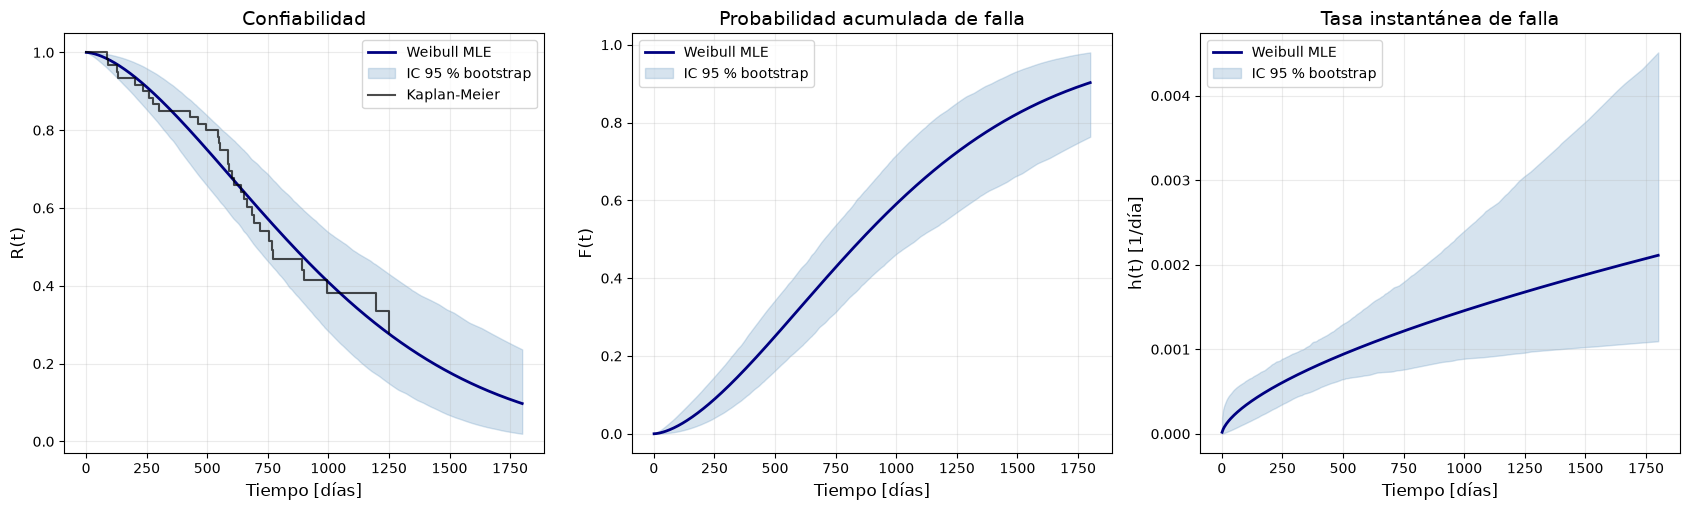

In [9]:
grid=np.linspace(1,1800,400)
def curves(beta,eta,x):
    R=np.exp(-(x/eta)**beta); F=1-R; h=(beta/eta)*(x/eta)**(beta-1)
    return R,F,h
R,F,h=curves(beta_mle,eta_mle,grid)
# Bandas puntuales desde parámetros bootstrap
R_b=[]; F_b=[]; h_b=[]
for bb,ee in boot[["beta","eta"]].to_numpy():
    rr,ff,hh=curves(bb,ee,grid); R_b.append(rr); F_b.append(ff); h_b.append(hh)
R_b,F_b,h_b=map(np.asarray,(R_b,F_b,h_b))

def band(a): return np.quantile(a,.025,axis=0),np.quantile(a,.975,axis=0)
Rlo,Rhi=band(R_b); Flo,Fhi=band(F_b); hlo,hhi=band(h_b)

fig,ax=plt.subplots(1,3,figsize=(17,5.2))
for a,y,lo,hi,title,ylab in [
    (ax[0],R,Rlo,Rhi,"Confiabilidad","R(t)"),
    (ax[1],F,Flo,Fhi,"Probabilidad acumulada de falla","F(t)"),
    (ax[2],h,hlo,hhi,"Tasa instantánea de falla","h(t) [1/día]")]:
    a.plot(grid,y,lw=2,color="navy",label="Weibull MLE")
    a.fill_between(grid,lo,hi,alpha=.22,color="steelblue",label="IC 95 % bootstrap")
    a.set(xlabel="Tiempo [días]",ylabel=ylab,title=title); a.grid(alpha=.25)
ax[0].step(np.r_[0,km.tiempo],np.r_[1,km.R_KM],where="post",color="black",alpha=.7,label="Kaplan-Meier")
ax[0].legend(); ax[1].legend(); ax[2].legend(); plt.tight_layout(); plt.show()

## 10. Intervalos en tiempos específicos

Una banda de confianza no es una banda de predicción para una bomba individual. La banda mide incertidumbre sobre la curva poblacional estimada. A continuación se reportan estimación e IC puntual al 95 % para 365, 730, 1.000 y 1.200 días.

In [10]:
times=np.array([365,730,1000,1200],float)
rows=[]
for x in times:
    R0,F0,h0=curves(beta_mle,eta_mle,np.array([x]))
    rb=[]; hb=[]
    for bb,ee in boot[["beta","eta"]].to_numpy():
        rr,ff,hh=curves(bb,ee,np.array([x])); rb.append(rr[0]); hb.append(hh[0])
    rb=np.array(rb); hb=np.array(hb)
    rows.append((x,R0[0],*np.quantile(rb,[.025,.975]),F0[0],h0[0],*np.quantile(hb,[.025,.975])))
tabla_t=pd.DataFrame(rows,columns=["t_dias","R","R_IC_inf","R_IC_sup","F","h_por_dia","h_IC_inf","h_IC_sup"])
display(tabla_t.style.format({"R":"{:.2%}","R_IC_inf":"{:.2%}","R_IC_sup":"{:.2%}","F":"{:.2%}","h_por_dia":"{:.6f}","h_IC_inf":"{:.6f}","h_IC_sup":"{:.6f}"}))

,t_dias,R,R_IC_inf,R_IC_sup,F,h_por_dia,h_IC_inf,h_IC_sup
0,365.000000,84.16%,76.76%,91.15%,15.84%,0.000771,0.000496,0.001056
1,730.000000,58.60%,47.79%,69.83%,41.40%,0.001194,0.000752,0.001753
2,1000.000000,40.94%,28.30%,53.78%,59.06%,0.001457,0.000888,0.002401
3,1200.000000,30.05%,17.18%,45.29%,69.95%,0.001634,0.000946,0.002913


## 11. Decisión de reutilización con confiabilidad residual

Para una bomba con edad acumulada $a$ y horizonte adicional de 365 días:

$$R_{res}(365\mid a)=\frac{R(a+365)}{R(a)}
=\exp\left[-\left(\frac{a+365}{\eta}\right)^\beta+\left(\frac{a}{\eta}\right)^\beta\right].$$

Si $\beta>1$, sobrevivir hasta una edad avanzada no “rejuvenece” la bomba: el riesgo instantáneo aumenta con la edad. Por ello, restar edad al B50 o al MTBF puede ser engañoso.

Se calcula el límite inferior bootstrap al 95 %. Un criterio conservador puede exigir que dicho límite, y no solo la estimación puntual, supere 50 %. Este umbral es ilustrativo y debe alinearse con consecuencia, costo y tolerancia de riesgo.

,edad_actual_dias,P_365_adicional,IC95_inf,IC95_sup,decision_estadistica
0,0.000000,84.2%,76.8%,91.2%,Cumple
1,200.000000,75.0%,67.3%,82.7%,Cumple
2,450.000000,67.2%,56.3%,77.0%,Cumple
3,650.000000,62.3%,48.5%,74.5%,No cumple criterio conservador
4,850.000000,58.2%,40.4%,72.1%,No cumple criterio conservador
5,1000.000000,55.4%,35.2%,71.0%,No cumple criterio conservador


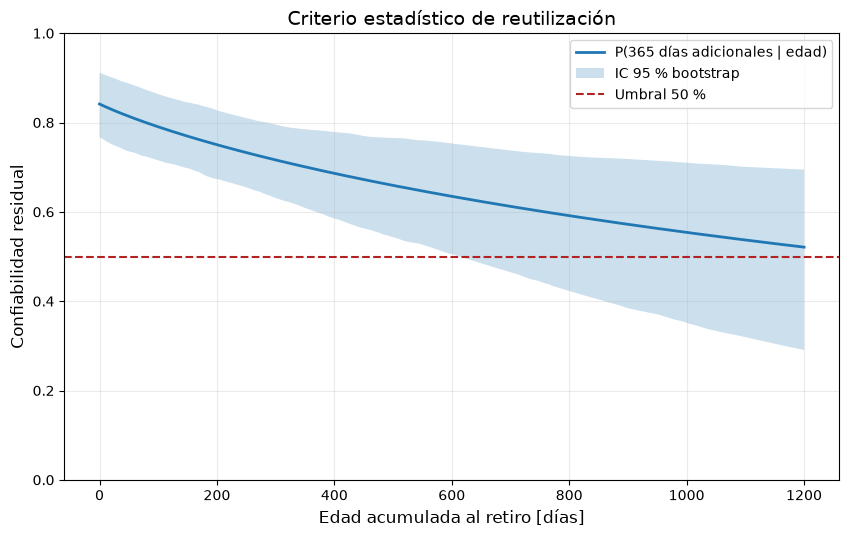

In [11]:
def residual_R(age,delta,beta,eta):
    return np.exp(-((age+delta)/eta)**beta+(age/eta)**beta)

ages=np.array([0,200,450,650,850,1000],float); delta=365.; rows=[]
for age in ages:
    est=residual_R(age,delta,beta_mle,eta_mle)
    vals=np.array([residual_R(age,delta,bb,ee) for bb,ee in boot[["beta","eta"]].to_numpy()])
    lo,hi=np.quantile(vals,[.025,.975])
    rows.append((age,est,lo,hi,"Cumple" if lo>.50 else "No cumple criterio conservador"))
reuse=pd.DataFrame(rows,columns=["edad_actual_dias","P_365_adicional","IC95_inf","IC95_sup","decision_estadistica"])
display(reuse.style.format({"P_365_adicional":"{:.1%}","IC95_inf":"{:.1%}","IC95_sup":"{:.1%}"}))

age_grid=np.linspace(0,1200,250); est=[]; lo=[]; hi=[]
for a in age_grid:
    vals=np.array([residual_R(a,365,bb,ee) for bb,ee in boot[["beta","eta"]].to_numpy()])
    est.append(residual_R(a,365,beta_mle,eta_mle)); lo.append(np.quantile(vals,.025)); hi.append(np.quantile(vals,.975))
fig,ax=plt.subplots(figsize=(10,5.8)); ax.plot(age_grid,est,lw=2,label="P(365 días adicionales | edad)")
ax.fill_between(age_grid,lo,hi,alpha=.23,label="IC 95 % bootstrap"); ax.axhline(.5,color="firebrick",ls="--",label="Umbral 50 %")
ax.set(xlabel="Edad acumulada al retiro [días]",ylabel="Confiabilidad residual",title="Criterio estadístico de reutilización",ylim=(0,1)); ax.legend(); ax.grid(alpha=.25); plt.show()

## 12. Simulación Monte Carlo predictiva de vida residual

El bootstrap anterior estima incertidumbre de parámetros. Ahora Monte Carlo genera resultados futuros. Para una bomba que sobrevivió hasta edad $a$, la vida total condicional se simula como:

$$T_{cond}=\eta\left[\left(\frac{a}{\eta}\right)^\beta-\ln(U)\right]^{1/\beta},\qquad U\sim Uniforme(0,1).$$

La vida residual es $L=T_{cond}-a$. Esta operación es correcta para una Weibull condicionada a $T>a$ y evita simular desde cero y restar la edad.

En cada réplica se realizan cinco operaciones: seleccionar $(\beta,\eta)$ desde el bootstrap, generar $U$, calcular $T_{cond}$, obtener $L$ y evaluar si $L>365$. Con parámetros fijos se representa variabilidad entre bombas. Seleccionando parámetros bootstrap se añade incertidumbre paramétrica.

In [12]:
def simular_vida_residual(edad_actual, n_sim=50_000, incertidumbre_param=True, seed=SEED+200):
    g=np.random.default_rng(seed)
    u=g.uniform(np.finfo(float).eps,1.0,n_sim)
    if incertidumbre_param:
        idx=g.integers(0,len(boot),n_sim)
        beta_s=boot.iloc[idx].beta.to_numpy(); eta_s=boot.iloc[idx].eta.to_numpy()
    else:
        beta_s=np.full(n_sim,beta_mle); eta_s=np.full(n_sim,eta_mle)
    vida_total=eta_s*((edad_actual/eta_s)**beta_s-np.log(u))**(1/beta_s)
    vida_residual=np.maximum(vida_total-edad_actual,0)
    return pd.DataFrame({"vida_total":vida_total,"vida_residual":vida_residual,"beta":beta_s,"eta":eta_s})

prueba=simular_vida_residual(450,2000,True,123)
assert (prueba.vida_total>=450).all() and (prueba.vida_residual>=0).all()
print("Pruebas de simulación condicional superadas")

Pruebas de simulación condicional superadas


## 13. Distribución predictiva y comparación de edades

Los percentiles siguientes describen vidas residuales de bombas futuras bajo los supuestos. No son intervalos de confianza de los parámetros. Para disponibilidad o vida, P10 es una medida conservadora; P90 representa una cola favorable.

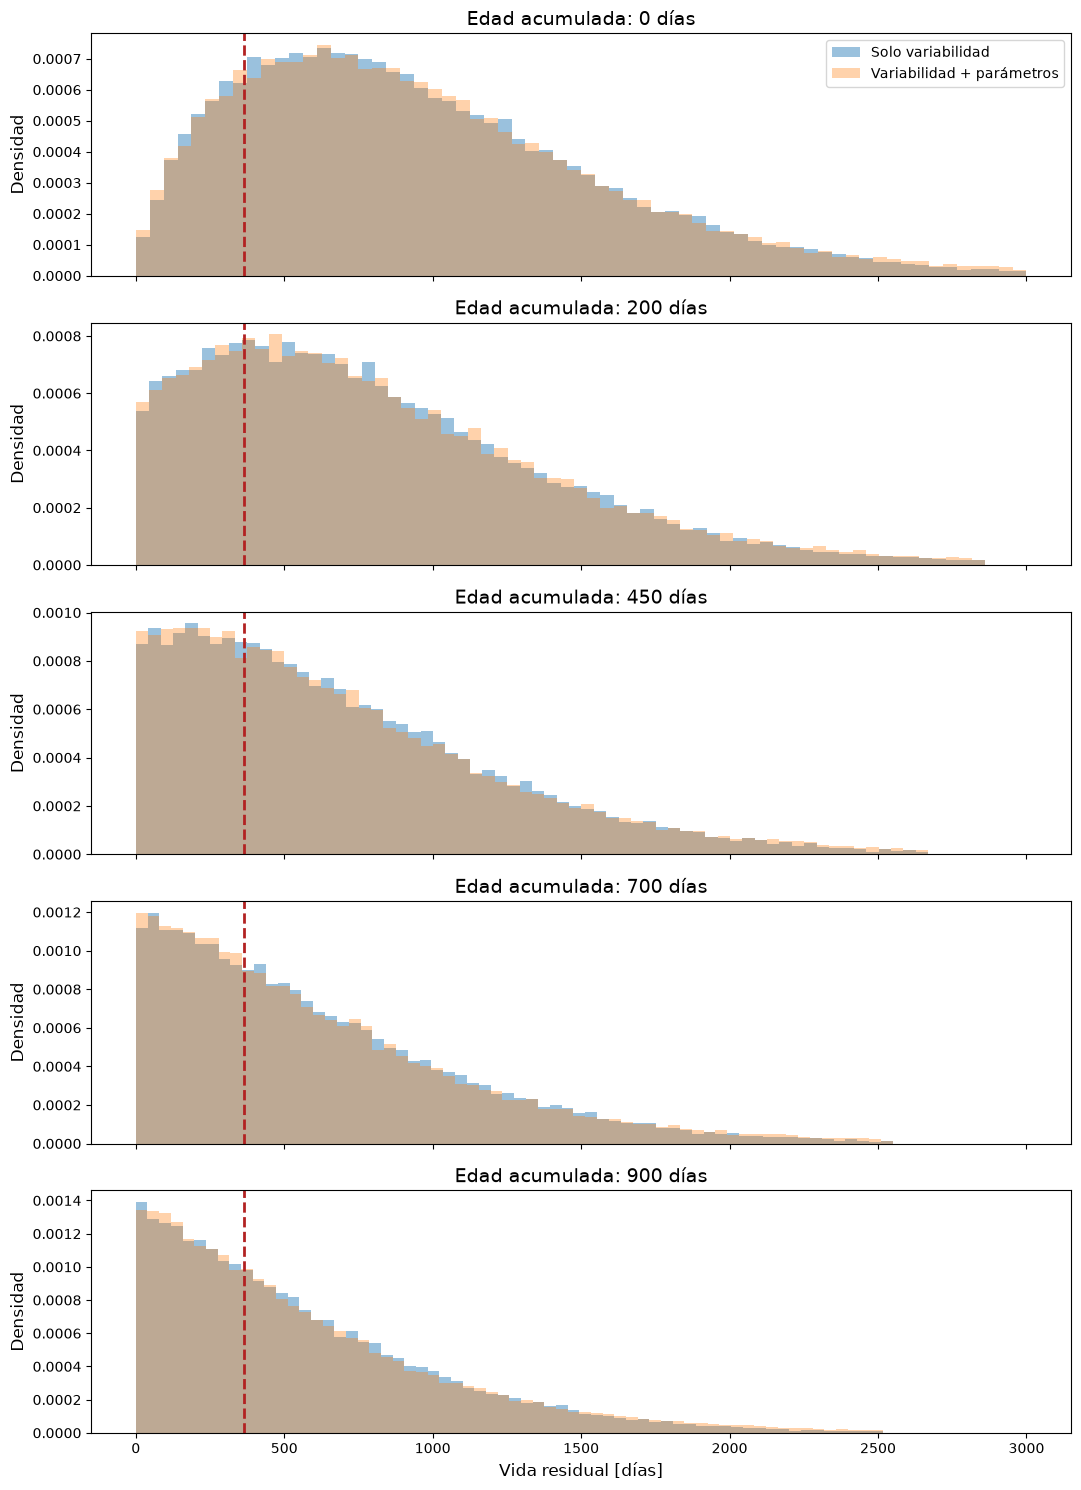

,edad,P2.5,P10,P50,P90,P97.5,P_superar_365
0,0,110.1,269.2,865.9,1838.3,2575.2,84.2%
1,200,44.1,163.5,706.8,1663.2,2379.3,75.5%
2,450,27.7,110.2,576.1,1494.2,2197.6,66.9%
3,700,21.5,85.4,490.3,1367.2,2090.6,60.6%
4,900,18.0,75.3,441.2,1289.2,1994.1,57.0%


In [13]:
edades=[0,200,450,700,900]
filas=[]; simulaciones={}
fig,axes=plt.subplots(len(edades),1,figsize=(11,15),sharex=True)
for ax,edad in zip(axes,edades):
    fijo=simular_vida_residual(edad,40_000,False,SEED+edad+10)
    total=simular_vida_residual(edad,40_000,True,SEED+edad+20)
    simulaciones[edad]=total
    lim=min(total.vida_residual.quantile(.99),3000); bins=np.linspace(0,lim,65)
    ax.hist(fijo.vida_residual,bins=bins,density=True,alpha=.45,label="Solo variabilidad")
    ax.hist(total.vida_residual,bins=bins,density=True,alpha=.35,label="Variabilidad + parámetros")
    ax.axvline(365,color="firebrick",ls="--",lw=2)
    q=total.vida_residual.quantile([.025,.10,.50,.90,.975])
    filas.append((edad,q.loc[.025],q.loc[.10],q.loc[.50],q.loc[.90],q.loc[.975],(total.vida_residual>365).mean()))
    ax.set_title(f"Edad acumulada: {edad} días"); ax.set_ylabel("Densidad")
axes[0].legend(); axes[-1].set_xlabel("Vida residual [días]"); plt.tight_layout(); plt.show()
resumen_mc=pd.DataFrame(filas,columns=["edad","P2.5","P10","P50","P90","P97.5","P_superar_365"])
display(resumen_mc.style.format({"P2.5":"{:.1f}","P10":"{:.1f}","P50":"{:.1f}","P90":"{:.1f}","P97.5":"{:.1f}","P_superar_365":"{:.1%}"}))

## 14. Verificación analítica de Monte Carlo

Con parámetros MLE fijos, la proporción simulada $P(L>365)$ debe aproximar $R(a+365)/R(a)$. Esta comparación verifica el algoritmo, pero no valida el modelo frente al activo.

In [14]:
filas=[]
for edad in edades:
    z=simular_vida_residual(edad,100_000,False,SEED+edad+100)
    p_mc=(z.vida_residual>365).mean(); p_an=residual_R(edad,365,beta_mle,eta_mle)
    filas.append((edad,p_an,p_mc,p_mc-p_an))
validacion_mc=pd.DataFrame(filas,columns=["edad","P_analitica","P_MonteCarlo","error_numerico"])
display(validacion_mc.style.format({"P_analitica":"{:.3%}","P_MonteCarlo":"{:.3%}","error_numerico":"{:.3%}"}))

,edad,P_analitica,P_MonteCarlo,error_numerico
0,0,84.156%,84.002%,-0.154%
1,200,75.037%,75.059%,0.022%
2,450,67.242%,67.149%,-0.093%
3,700,61.229%,61.254%,0.025%
4,900,57.213%,57.500%,0.287%


## 15. Convergencia y error numérico

Más réplicas reducen error Monte Carlo, pero no corrigen una distribución inadecuada. Para una proporción, $SE_{MC}=\sqrt{\hat p(1-\hat p)/N}$. Se revisan la probabilidad y los percentiles porque las colas suelen converger más lentamente que la media.

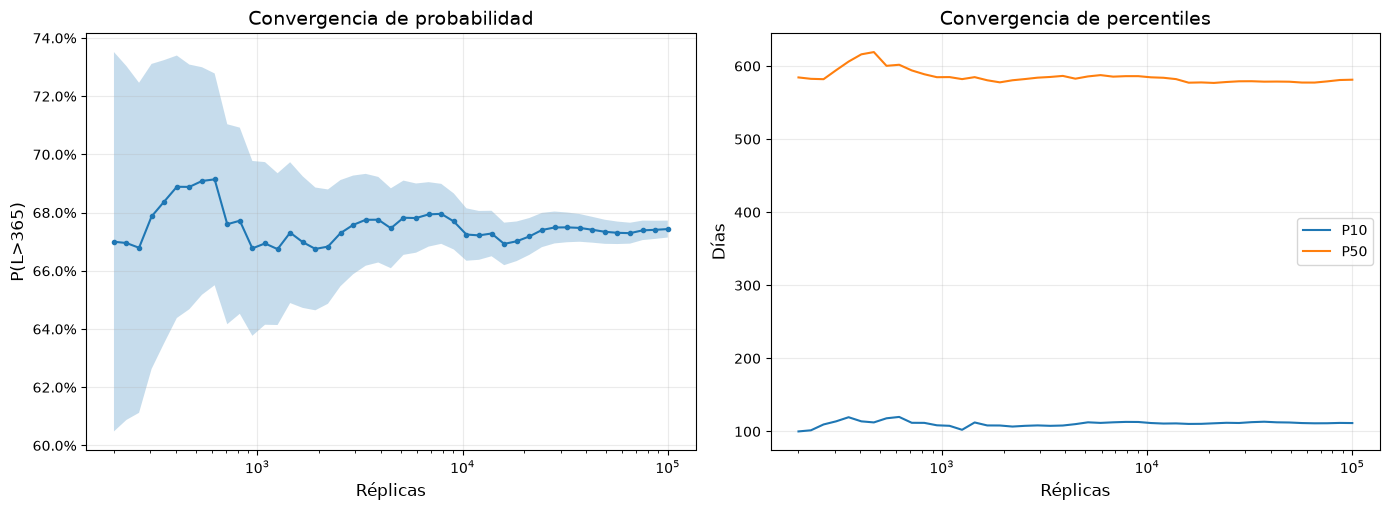

,semilla_id,P365,P10,P50
0,0,67.23%,110.7,580.3
1,1,67.59%,115.3,577.6
2,2,67.12%,114.7,575.7
3,3,67.77%,112.1,585.8
4,4,66.42%,113.2,575.4
5,5,67.14%,112.4,573.1
6,6,67.20%,113.4,575.6
7,7,68.11%,112.0,590.4
8,8,67.34%,111.9,585.1
9,9,67.33%,110.7,576.9


In [15]:
Ngrid=np.unique(np.geomspace(200,100_000,45).astype(int))
z=simular_vida_residual(450,100_000,True,SEED+500); L=z.vida_residual.to_numpy(); rows=[]
for N in Ngrid:
    p=(L[:N]>365).mean(); se=np.sqrt(max(p*(1-p),1e-12)/N)
    rows.append((N,p,se,np.quantile(L[:N],.10),np.quantile(L[:N],.50)))
conv=pd.DataFrame(rows,columns=["N","P365","SE_MC","P10","P50"])
fig,ax=plt.subplots(1,2,figsize=(14,5.2))
ax[0].plot(conv.N,conv.P365,'o-',ms=3); ax[0].fill_between(conv.N,np.clip(conv.P365-1.96*conv.SE_MC,0,1),np.clip(conv.P365+1.96*conv.SE_MC,0,1),alpha=.25)
ax[0].set(xscale="log",xlabel="Réplicas",ylabel="P(L>365)",title="Convergencia de probabilidad"); ax[0].yaxis.set_major_formatter(lambda y,pos:f"{y:.1%}")
ax[1].plot(conv.N,conv.P10,label="P10"); ax[1].plot(conv.N,conv.P50,label="P50"); ax[1].set(xscale="log",xlabel="Réplicas",ylabel="Días",title="Convergencia de percentiles"); ax[1].legend()
for a in ax: a.grid(alpha=.25)
plt.tight_layout(); plt.show()

semillas=[]
for k in range(10):
    s=simular_vida_residual(450,20_000,True,SEED+600+k)
    semillas.append((k,(s.vida_residual>365).mean(),s.vida_residual.quantile(.10),s.vida_residual.median()))
display(pd.DataFrame(semillas,columns=["semilla_id","P365","P10","P50"]).style.format({"P365":"{:.2%}","P10":"{:.1f}","P50":"{:.1f}"}))

## 16. Simulación económica: reutilizar frente a reemplazar

Ejemplo sintético: reacondicionar e instalar una usada cuesta 45.000 USD; instalar nueva cuesta 115.000 USD; una falla antes de 365 días agrega 180.000 USD. La bomba nueva se representa, solo para ilustración, con Weibull $\beta=1,8$ y $\eta=1.450$ días. Sustituya estos valores por costos, consecuencias y distribución corporativa antes de decidir.

In [16]:
COSTO_REUSO,COSTO_NUEVA,CONSECUENCIA=45_000,115_000,180_000
BETA_NUEVA,ETA_NUEVA=1.8,1450.0

def costos_mc(edad,n=50_000,seed=SEED+700):
    g=np.random.default_rng(seed); r=simular_vida_residual(edad,n,True,seed)
    falla_r=r.vida_residual.le(365).to_numpy(); falla_n=(ETA_NUEVA*g.weibull(BETA_NUEVA,n))<=365
    return pd.DataFrame({"reusar":COSTO_REUSO+CONSECUENCIA*falla_r,
                         "nueva":COSTO_NUEVA+CONSECUENCIA*falla_n,
                         "falla_reusar":falla_r,"falla_nueva":falla_n})
rows=[]
for edad in [200,450,700,900]:
    z=costos_mc(edad,50_000,SEED+700+edad)
    rows.append((edad,z.reusar.mean(),z.nueva.mean(),z.reusar.quantile(.90),z.nueva.quantile(.90),z.falla_reusar.mean(),z.falla_nueva.mean()))
costos=pd.DataFrame(rows,columns=["edad","E_costo_reusar","E_costo_nueva","P90_reusar","P90_nueva","P_falla_reusar","P_falla_nueva"])
display(costos.style.format({"E_costo_reusar":"${:,.0f}","E_costo_nueva":"${:,.0f}","P90_reusar":"${:,.0f}","P90_nueva":"${:,.0f}","P_falla_reusar":"{:.1%}","P_falla_nueva":"{:.1%}"}))

,edad,E_costo_reusar,E_costo_nueva,P90_reusar,P90_nueva,P_falla_reusar,P_falla_nueva
0,200,"$89,507","$129,666","$225,000","$115,000",24.7%,8.1%
1,450,"$103,165","$129,368","$225,000","$115,000",32.3%,8.0%
2,700,"$115,135","$129,432","$225,000","$115,000",39.0%,8.0%
3,900,"$123,347","$129,360","$225,000","$115,000",43.5%,8.0%


## 17. Lectura integrada y límites de Monte Carlo

Monte Carlo aporta una distribución predictiva, separa de forma experimental variabilidad e incertidumbre paramétrica, comprueba convergencia y convierte resultados de confiabilidad en consecuencias económicas. Sin embargo, permanece condicionado al modelo Weibull, la independencia, la correcta clasificación de fallas y la estabilidad operacional. Más iteraciones reducen error numérico, no incertidumbre de modelo ni sesgos de datos.

## 18. Integración con inspección y prueba de banco

El componente estadístico no reemplaza criterios físicos. Una regla ilustrativa exige simultáneamente:

1. inspección y borescopio aprobados;
2. eficiencia de banco $\ge 50\%$;
3. media Weibull del modelo $>730$ días;
4. límite inferior del IC 95 % de $P(T>a+365\mid T>a)>50\%$.

La cuarta condición es más conservadora que usar únicamente la estimación puntual. En una aplicación corporativa debe evaluarse si el costo de un falso “reutilizar” es mucho mayor que el de un falso “descartar”.

In [17]:
candidatas=pd.DataFrame({
    "bomba":["Candidata-01","Candidata-02","Candidata-03"],
    "edad_dias":[200,450,700],"eficiencia_pct":[68,57,74],
    "inspeccion_aprobada":[True,True,False]})

def lower_residual(age):
    vals=[residual_R(age,365,bb,ee) for bb,ee in boot[["beta","eta"]].to_numpy()]
    return np.quantile(vals,.025)

candidatas["P365_estimado"]=[residual_R(a,365,beta_mle,eta_mle) for a in candidatas.edad_dias]
candidatas["P365_IC95_inf"]=[lower_residual(a) for a in candidatas.edad_dias]
candidatas["MTTF_modelo_dias"]=MTTF
candidatas["reutilizar"]=(candidatas.inspeccion_aprobada & candidatas.eficiencia_pct.ge(50) & (MTTF>730) & candidatas.P365_IC95_inf.gt(.50))
display(candidatas.style.format({"P365_estimado":"{:.1%}","P365_IC95_inf":"{:.1%}","MTTF_modelo_dias":"{:.0f}"}))

,bomba,edad_dias,eficiencia_pct,inspeccion_aprobada,P365_estimado,P365_IC95_inf,MTTF_modelo_dias,reutilizar
0,Candidata-01,200,68,True,75.0%,67.3%,959,True
1,Candidata-02,450,57,True,67.2%,56.3%,959,True
2,Candidata-03,700,74,False,61.2%,46.5%,959,False


## 19. Diagnóstico, límites y mejoras

### Qué se hizo bien
- Se conservaron censuras en lugar de tratarlas como fallas.
- Se comparó Kaplan-Meier, método gráfico y MLE.
- Se reportaron intervalos de confianza, no solo estimaciones puntuales.
- La decisión de reutilización usa confiabilidad condicional.

### Límites
- Datos sintéticos y un único modelo de bomba.
- Se supone independencia entre instalaciones. Una bomba reinstalada varias veces requiere estructura por unidad o efectos aleatorios.
- Weibull puede no representar mezclas de modos de falla.
- Bootstrap con 60 observaciones puede ser ancho e inestable en colas.
- No se incluyeron covariables como corte de agua, RPM, arena, fabricante, pozo o campaña.
- Un IC de curva no representa incertidumbre de modelo.

### Siguientes análisis recomendados
1. Separar modos de falla y distinguir riesgos competitivos.
2. Comparar Weibull, lognormal y exponencial mediante AIC, diagnóstico gráfico y plausibilidad física.
3. Usar regresión paramétrica o Cox si las condiciones operativas varían.
4. Modelar reinstalaciones repetidas por bomba.
5. Evaluar calibración temporal con datos fuera de muestra.
6. Definir el umbral de reutilización mediante costo esperado y consecuencia de falla, no solo 50 %.

## 20. Referencias

1. Labrador, L., Celis, J., Martin, J. L., Rubiano, E., Gutierrez, J., Monroy, M., Prada, J., & Obregon, C. (2015). *Reuse Selection Criteria for Progressive Cavity Pumps Based on the Mean Time between Failure and Reliability Function for Each Pump Type in the Cira Infantas Field* (SPE-173940-MS). SPE Artificial Lift Conference, Latin America and Caribbean.
2. NIST/SEMATECH. *A Weibull Maximum Likelihood Estimation Example*. https://www.itl.nist.gov/div898/handbook/apr/section4/apr413.htm
3. NIST/SEMATECH. *How Do You Estimate Life Distribution Parameters from Censored Data?* https://www.itl.nist.gov/div898/handbook/apr/section4/apr41.htm
4. Klein, J. P., & Moeschberger, M. L. (1997). *Survival Analysis: Techniques for Censored and Truncated Data*. Springer.

### Reproducibilidad
- Semilla: `173940`.
- Dependencias: NumPy, pandas, SciPy y Matplotlib.
- Bootstrap: 1.000 remuestras.
- Los datos son sintéticos y se generan dentro del cuaderno.